<a href="https://colab.research.google.com/github/EricaBordon/inteligencia-artificial/blob/main/trabajo-multiagente-churn/Clase08_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SISTEMA MULTIAGENTE - TELCO CUSTOMER CHURN
# Proyecto Académico - Inteligencia Artificial
# Dataset: TelcoCustomerChurn.csv (IBM Sample Dataset)

# Instalación de dependencias

In [1]:
!pip install -q transformers accelerate sentencepiece
!pip install -q scikit-learn pandas numpy matplotlib seaborn

#Imports globales

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import json
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Modelos de regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
print("✅ Librerías importadas correctamente")
print(f"📅 Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Librerías importadas correctamente
📅 Fecha de ejecución: 2026-06-15 23:03:29


In [3]:
df_original = pd.read_csv("TelcoCustomerChurn.csv")

print(df_original.shape)
df_original.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# AGENTE 1: NORMALIZADOR
Responsabilidad: Limpiar, transformar y preparar el dataset
Este agente actúa como un preprocesador inteligente que:
    * Carga el CSV desde la ruta especificada
    * Analiza la estructura del dataset
    * Detecta y trata valores nulos
    * Elimina duplicados
    * Codifica variables categóricas con LabelEncoder
    * Escala variables numéricas con StandardScaler
    * Guarda el dataset limpio para el siguiente agente

In [4]:
# ============================================================
# AGENTE 1: NORMALIZADOR
# Responsabilidad:
# - Cargar el dataset original
# - Analizar columnas
# - Limpiar datos
# - Imputar valores faltantes
# - Codificar variables categóricas
# - Escalar variables numéricas
# - Guardar dataset limpio
# ============================================================

class AgenteNormalizador:
    """
    Agente 1 del sistema multiagente.

    Este agente recibe un archivo CSV sin normalizar y lo transforma
    en un dataset limpio, numérico y listo para ser usado por el
    Agente 2 Entrenador.
    """

    def __init__(self, ruta_csv, columna_objetivo):
        self.ruta_csv = ruta_csv
        self.columna_objetivo = columna_objetivo

        self.df_original = None
        self.df_limpio = None

        self.columnas_numericas = []
        self.columnas_categoricas = []

        self.label_encoders = {}
        self.scaler = StandardScaler()

        self.reporte = {}

        print("=" * 60)
        print("AGENTE 1: NORMALIZADOR INICIADO")
        print("=" * 60)

    def cargar_dataset(self):
        """Carga el archivo CSV original."""
        print("\nCargando dataset...")

        self.df_original = pd.read_csv(self.ruta_csv)

        print(f"Filas originales: {self.df_original.shape[0]}")
        print(f"Columnas originales: {self.df_original.shape[1]}")
        print("Columnas del dataset:")
        print(list(self.df_original.columns))

        self.reporte["filas_originales"] = self.df_original.shape[0]
        self.reporte["columnas_originales"] = self.df_original.shape[1]

    def analizar_columnas(self):
        """
        Separa las columnas en numéricas y categóricas.
        No incluye la columna objetivo.
        """
        print("\nAnalizando columnas...")

        df_temp = self.df_original.drop(
            columns=[self.columna_objetivo],
            errors="ignore"
        )

        self.columnas_numericas = []
        self.columnas_categoricas = []

        for columna in df_temp.columns:
            if df_temp[columna].dtype == "object":
                self.columnas_categoricas.append(columna)
            else:
                self.columnas_numericas.append(columna)

        print(f"Columnas numéricas: {self.columnas_numericas}")
        print(f"Columnas categóricas: {self.columnas_categoricas}")

    def detectar_nulos(self):
        """Detecta valores nulos directos en el dataset."""
        print("\nDetectando valores nulos...")

        nulos = self.df_original.isnull().sum()
        total_nulos = nulos.sum()

        if total_nulos == 0:
            print("No se encontraron valores nulos directos.")
        else:
            print("Valores nulos encontrados:")
            print(nulos[nulos > 0])

        self.reporte["nulos_directos"] = int(total_nulos)

    def limpiar_dataset(self):
        """
        Limpia el dataset:
        - Copia el dataset original.
        - Elimina customerID porque es solo identificador.
        - Convierte TotalCharges a numérico.
        - Imputa nulos.
        - Elimina duplicados.
        """
        print("\nLimpiando dataset...")

        df = self.df_original.copy()

        # Eliminar columna identificadora
        if "customerID" in df.columns:
            df.drop(columns=["customerID"], inplace=True)
            print("Columna customerID eliminada.")

        # En este dataset TotalCharges suele venir como texto.
        # Se convierte a número; si hay espacios vacíos, pasan a NaN.
        if "TotalCharges" in df.columns:
            df["TotalCharges"] = pd.to_numeric(
                df["TotalCharges"],
                errors="coerce"
            )
            print("Columna TotalCharges convertida a numérica.")

        # Recalcular tipos de columnas después de convertir TotalCharges
        self.columnas_numericas = []
        self.columnas_categoricas = []

        df_temp = df.drop(
            columns=[self.columna_objetivo],
            errors="ignore"
        )

        for columna in df_temp.columns:
            if df_temp[columna].dtype == "object":
                self.columnas_categoricas.append(columna)
            else:
                self.columnas_numericas.append(columna)

        # Imputar columnas numéricas con la mediana
        for columna in self.columnas_numericas:
            if df[columna].isnull().sum() > 0:
                mediana = df[columna].median()
                df[columna] = df[columna].fillna(mediana)
                print(f"Nulos en {columna} imputados con mediana: {mediana}")

        # Imputar columnas categóricas con la moda
        for columna in self.columnas_categoricas:
            if df[columna].isnull().sum() > 0:
                moda = df[columna].mode()[0]
                df[columna] = df[columna].fillna(moda)
                print(f"Nulos en {columna} imputados con moda: {moda}")

        # Eliminar duplicados
        duplicados = df.duplicated().sum()
        df.drop_duplicates(inplace=True)

        print(f"Duplicados eliminados: {duplicados}")

        self.df_limpio = df

        self.reporte["duplicados_eliminados"] = int(duplicados)
        self.reporte["filas_limpias"] = df.shape[0]
        self.reporte["columnas_limpias"] = df.shape[1]

        print(f"Dataset limpio: {df.shape[0]} filas x {df.shape[1]} columnas")

    def codificar_categoricas(self):
        """
        Convierte variables categóricas a números usando LabelEncoder.
        Esto es necesario porque los modelos de Machine Learning trabajan
        con valores numéricos.
        """
        print("\nCodificando variables categóricas...")

        for columna in self.columnas_categoricas:
            encoder = LabelEncoder()

            self.df_limpio[columna] = encoder.fit_transform(
                self.df_limpio[columna].astype(str)
            )

            self.label_encoders[columna] = encoder

            print(f"Columna codificada: {columna}")

        # Codificar también la columna objetivo si es categórica
        if self.df_limpio[self.columna_objetivo].dtype == "object":
            encoder_objetivo = LabelEncoder()

            self.df_limpio[self.columna_objetivo] = encoder_objetivo.fit_transform(
                self.df_limpio[self.columna_objetivo].astype(str)
            )

            self.label_encoders[self.columna_objetivo] = encoder_objetivo

            print(f"Columna objetivo codificada: {self.columna_objetivo}")
            print(
                dict(
                    zip(
                        encoder_objetivo.classes_,
                        encoder_objetivo.transform(encoder_objetivo.classes_)
                    )
                )
            )

    def escalar_numericas(self):
        """
        Escala las columnas numéricas con StandardScaler.
        Esto deja los datos con media 0 y desviación estándar 1.
        """
        print("\nEscalando columnas numéricas...")

        columnas_a_escalar = [
            columna for columna in self.columnas_numericas
            if columna != self.columna_objetivo
        ]

        if len(columnas_a_escalar) > 0:
            self.df_limpio[columnas_a_escalar] = self.scaler.fit_transform(
                self.df_limpio[columnas_a_escalar]
            )

            print("Columnas escaladas:")
            print(columnas_a_escalar)
        else:
            print("No hay columnas numéricas para escalar.")

    def visualizar_objetivo(self):
        """
        Muestra un gráfico simple de la variable objetivo.
        Sirve para observar si las clases están balanceadas.
        """
        print("\nGenerando gráfico de la variable objetivo...")

        conteo = self.df_limpio[self.columna_objetivo].value_counts()

        plt.figure(figsize=(6, 4))
        conteo.plot(kind="bar")
        plt.title(f"Distribución de la variable objetivo: {self.columna_objetivo}")
        plt.xlabel("Clase")
        plt.ylabel("Cantidad")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def guardar_dataset_limpio(self, ruta_salida="dataset_limpio.csv"):
        """Guarda el dataset limpio en un nuevo archivo CSV."""
        self.df_limpio.to_csv(ruta_salida, index=False)

        self.reporte["ruta_dataset_limpio"] = ruta_salida

        print(f"\nDataset limpio guardado como: {ruta_salida}")

    def ejecutar(self):
        """
        Ejecuta todo el proceso del Agente 1 en orden.
        """
        self.cargar_dataset()
        self.analizar_columnas()
        self.detectar_nulos()
        self.limpiar_dataset()
        self.codificar_categoricas()
        self.escalar_numericas()
        self.visualizar_objetivo()
        self.guardar_dataset_limpio()

        print("\nAGENTE 1 COMPLETADO")
        print("Reporte del proceso:")
        print(self.reporte)

        return self.df_limpio, self.reporte

AGENTE 1: NORMALIZADOR INICIADO

Cargando dataset...
Filas originales: 7043
Columnas originales: 21
Columnas del dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Analizando columnas...
Columnas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Columnas categóricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Detectando valores nulos...
No se encontraron valores nulos directos.

Limpiando dataset...
Columna customerID eliminada.
Columna TotalCharges convertida a numérica.
Nulos

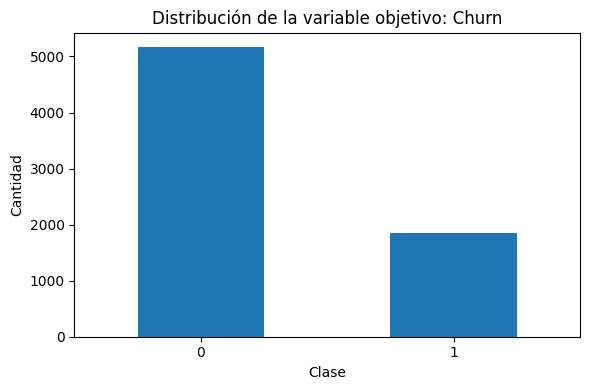


Dataset limpio guardado como: dataset_limpio.csv

AGENTE 1 COMPLETADO
Reporte del proceso:
{'filas_originales': 7043, 'columnas_originales': 21, 'nulos_directos': 0, 'duplicados_eliminados': 22, 'filas_limpias': 7021, 'columnas_limpias': 20, 'ruta_dataset_limpio': 'dataset_limpio.csv'}


In [5]:
agente1 = AgenteNormalizador(
    ruta_csv="TelcoCustomerChurn.csv",
    columna_objetivo="Churn"
)

df_limpio, reporte_normalizacion = agente1.ejecutar()

#
# AGENTE 2: ENTRENADOR
# Responsabilidad:
# - Recibir el dataset limpio del Agente 1
# - Detectar si el problema es clasificación o regresión
# - Dividir datos en entrenamiento y prueba
# - Entrenar varios modelos candidatos
# - Evaluar métricas
# - Seleccionar el mejor modelo
#

In [6]:
# ============================================================
# AGENTE 2: ENTRENADOR
# Responsabilidad:
# - Recibir el dataset limpio del Agente 1
# - Detectar si el problema es clasificación o regresión
# - Dividir datos en entrenamiento y prueba
# - Entrenar varios modelos candidatos
# - Evaluar métricas
# - Seleccionar el mejor modelo
# ============================================================

class AgenteEntrenador:
    """
    Agente 2 del sistema multiagente.

    Este agente recibe el dataset ya normalizado y se encarga de
    entrenar varios modelos de Machine Learning para seleccionar
    automáticamente el que tenga mejor rendimiento.
    """

    def __init__(self, df, columna_objetivo, test_size=0.2):
        self.df = df
        self.columna_objetivo = columna_objetivo
        self.test_size = test_size

        self.tipo_problema = None
        self.modelos = {}
        self.resultados = {}

        self.mejor_modelo = None
        self.mejor_nombre = None
        self.mejor_metrica = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        print("=" * 60)
        print("AGENTE 2: ENTRENADOR INICIADO")
        print("=" * 60)

    def detectar_tipo_problema(self):
        """
        Detecta automáticamente si el problema es de clasificación o regresión.

        Regla usada:
        - Si la variable objetivo tiene pocos valores únicos, se asume clasificación.
        - Si tiene muchos valores únicos, se asume regresión.
        """
        valores_unicos = self.df[self.columna_objetivo].nunique()
        tipo_dato = self.df[self.columna_objetivo].dtype

        if valores_unicos <= 10 or tipo_dato == "object":
            self.tipo_problema = "clasificacion"
        else:
            self.tipo_problema = "regresion"

        print("\nTipo de problema detectado:")
        print(f"Variable objetivo: {self.columna_objetivo}")
        print(f"Valores únicos: {valores_unicos}")
        print(f"Tipo de dato: {tipo_dato}")
        print(f"Problema: {self.tipo_problema.upper()}")

    def preparar_datos(self):
        """
        Separa las variables predictoras X y la variable objetivo y.
        Luego divide los datos en entrenamiento y prueba.
        """
        print("\nPreparando datos...")

        X = self.df.drop(columns=[self.columna_objetivo])
        y = self.df[self.columna_objetivo]

        if self.tipo_problema == "clasificacion":
            self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
                X,
                y,
                test_size=self.test_size,
                random_state=42,
                stratify=y
            )
        else:
            self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
                X,
                y,
                test_size=self.test_size,
                random_state=42
            )

        print(f"Total de registros: {len(y)}")
        print(f"Datos de entrenamiento: {len(self.X_train)}")
        print(f"Datos de prueba: {len(self.X_test)}")
        print(f"Cantidad de variables predictoras: {X.shape[1]}")

    def seleccionar_modelos(self):
        """
        Selecciona automáticamente modelos candidatos según el tipo de problema.
        """
        print("\nSeleccionando modelos candidatos...")

        if self.tipo_problema == "clasificacion":
            self.modelos = {
                "Regresion Logistica": LogisticRegression(max_iter=1000, random_state=42),
                "Arbol de Decision": DecisionTreeClassifier(max_depth=10, random_state=42),
                "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
                "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
                "KNN": KNeighborsClassifier(n_neighbors=5)
            }

        else:
            self.modelos = {
                "Regresion Lineal": LinearRegression(),
                "Ridge": Ridge(alpha=1.0),
                "Lasso": Lasso(alpha=0.1),
                "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
                "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42)
            }

        for nombre_modelo in self.modelos:
            print(f"Modelo agregado: {nombre_modelo}")

    def entrenar_y_evaluar(self):
        """
        Entrena cada modelo y calcula sus métricas.
        """
        print("\nEntrenando y evaluando modelos...")

        for nombre, modelo in self.modelos.items():
            print(f"\nEntrenando modelo: {nombre}")

            modelo.fit(self.X_train, self.y_train)
            y_pred = modelo.predict(self.X_test)

            if self.tipo_problema == "clasificacion":
                accuracy = accuracy_score(self.y_test, y_pred)
                precision = precision_score(
                    self.y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )
                recall = recall_score(
                    self.y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )
                f1 = f1_score(
                    self.y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                self.resultados[nombre] = {
                    "modelo": modelo,
                    "accuracy": accuracy,
                    "precision": precision,
                    "recall": recall,
                    "f1_score": f1,
                    "y_pred": y_pred
                }

                print(f"Accuracy: {accuracy:.4f}")
                print(f"Precision: {precision:.4f}")
                print(f"Recall: {recall:.4f}")
                print(f"F1-score: {f1:.4f}")

            else:
                mae = mean_absolute_error(self.y_test, y_pred)
                mse = mean_squared_error(self.y_test, y_pred)
                rmse = np.sqrt(mse)
                r2 = r2_score(self.y_test, y_pred)

                self.resultados[nombre] = {
                    "modelo": modelo,
                    "MAE": mae,
                    "MSE": mse,
                    "RMSE": rmse,
                    "R2": r2,
                    "y_pred": y_pred
                }

                print(f"MAE: {mae:.4f}")
                print(f"MSE: {mse:.4f}")
                print(f"RMSE: {rmse:.4f}")
                print(f"R2: {r2:.4f}")

    def seleccionar_mejor_modelo(self):
        """
        Selecciona el mejor modelo según la métrica principal:
        - Clasificación: F1-score
        - Regresión: R2
        """
        print("\nSeleccionando mejor modelo...")

        if self.tipo_problema == "clasificacion":
            metrica_principal = "f1_score"
        else:
            metrica_principal = "R2"

        mejor_valor = -1

        for nombre, resultado in self.resultados.items():
            valor = resultado[metrica_principal]

            if valor > mejor_valor:
                mejor_valor = valor
                self.mejor_nombre = nombre
                self.mejor_modelo = resultado["modelo"]
                self.mejor_metrica = valor

        print(f"Mejor modelo seleccionado: {self.mejor_nombre}")
        print(f"Métrica principal ({metrica_principal}): {self.mejor_metrica:.4f}")

    def mostrar_resumen_modelos(self):
        """
        Muestra una tabla resumen con las métricas de todos los modelos.
        """
        print("\nResumen comparativo de modelos:")

        resumen = []

        for nombre, resultado in self.resultados.items():
            fila = {"modelo": nombre}

            for clave, valor in resultado.items():
                if clave not in ["modelo", "y_pred"]:
                    fila[clave] = round(valor, 4)

            resumen.append(fila)

        df_resumen = pd.DataFrame(resumen)
        display(df_resumen)

        return df_resumen

    def graficar_comparacion(self):
        """
        Genera un gráfico comparando los modelos según la métrica principal.
        """
        if self.tipo_problema == "clasificacion":
            metrica = "f1_score"
        else:
            metrica = "R2"

        nombres = list(self.resultados.keys())
        valores = [self.resultados[nombre][metrica] for nombre in nombres]

        plt.figure(figsize=(10, 5))
        plt.bar(nombres, valores)
        plt.title(f"Comparación de modelos según {metrica}")
        plt.xlabel("Modelo")
        plt.ylabel(metrica)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    def mostrar_matriz_confusion(self):
        """
        Muestra la matriz de confusión del mejor modelo.
        Solo aplica para clasificación.
        """
        if self.tipo_problema != "clasificacion":
            return

        print("\nMatriz de confusión del mejor modelo:")

        y_pred_mejor = self.resultados[self.mejor_nombre]["y_pred"]
        matriz = confusion_matrix(self.y_test, y_pred_mejor)

        plt.figure(figsize=(5, 4))
        sns.heatmap(
            matriz,
            annot=True,
            fmt="d",
            cmap="Blues"
        )
        plt.title(f"Matriz de confusión - {self.mejor_nombre}")
        plt.xlabel("Predicción")
        plt.ylabel("Valor real")
        plt.tight_layout()
        plt.show()

    def obtener_resultados(self):
        """
        Retorna los datos principales del entrenamiento para el Agente 3.
        """
        metricas_mejor_modelo = self.resultados[self.mejor_nombre].copy()
        metricas_mejor_modelo.pop("modelo", None)
        metricas_mejor_modelo.pop("y_pred", None)

        return {
            "tipo_problema": self.tipo_problema,
            "mejor_modelo": self.mejor_nombre,
            "mejor_metrica": self.mejor_metrica,
            "metricas": metricas_mejor_modelo,
            "todos_los_modelos": {
                nombre: {
                    clave: valor
                    for clave, valor in resultado.items()
                    if clave not in ["modelo", "y_pred"]
                }
                for nombre, resultado in self.resultados.items()
            }
        }

    def ejecutar(self):
        """
        Ejecuta todo el flujo del Agente 2.
        """
        self.detectar_tipo_problema()
        self.preparar_datos()
        self.seleccionar_modelos()
        self.entrenar_y_evaluar()
        self.seleccionar_mejor_modelo()
        resumen_modelos = self.mostrar_resumen_modelos()
        self.graficar_comparacion()
        self.mostrar_matriz_confusion()

        print("\nAGENTE 2 COMPLETADO")
        print("Modelo listo para el Agente 3 Comunicador.")

        return self.obtener_resultados(), resumen_modelos

AGENTE 2: ENTRENADOR INICIADO

Tipo de problema detectado:
Variable objetivo: Churn
Valores únicos: 2
Tipo de dato: int64
Problema: CLASIFICACION

Preparando datos...
Total de registros: 7021
Datos de entrenamiento: 5616
Datos de prueba: 1405
Cantidad de variables predictoras: 19

Seleccionando modelos candidatos...
Modelo agregado: Regresion Logistica
Modelo agregado: Arbol de Decision
Modelo agregado: Random Forest
Modelo agregado: Gradient Boosting
Modelo agregado: KNN

Entrenando y evaluando modelos...

Entrenando modelo: Regresion Logistica
Accuracy: 0.8000
Precision: 0.7904
Recall: 0.8000
F1-score: 0.7928

Entrenando modelo: Arbol de Decision
Accuracy: 0.7495
Precision: 0.7429
Recall: 0.7495
F1-score: 0.7457

Entrenando modelo: Random Forest
Accuracy: 0.7801
Precision: 0.7653
Recall: 0.7801
F1-score: 0.7676

Entrenando modelo: Gradient Boosting
Accuracy: 0.8007
Precision: 0.7903
Recall: 0.8007
F1-score: 0.7922

Entrenando modelo: KNN
Accuracy: 0.7516
Precision: 0.7426
Recall: 0.7

,modelo,accuracy,precision,recall,f1_score
0,Regresion Logistica,0.8000,0.7904,0.8000,0.7928
1,Arbol de Decision,0.7495,0.7429,0.7495,0.7457
2,Random Forest,0.7801,0.7653,0.7801,0.7676
3,Gradient Boosting,0.8007,0.7903,0.8007,0.7922
4,KNN,0.7516,0.7426,0.7516,0.7463


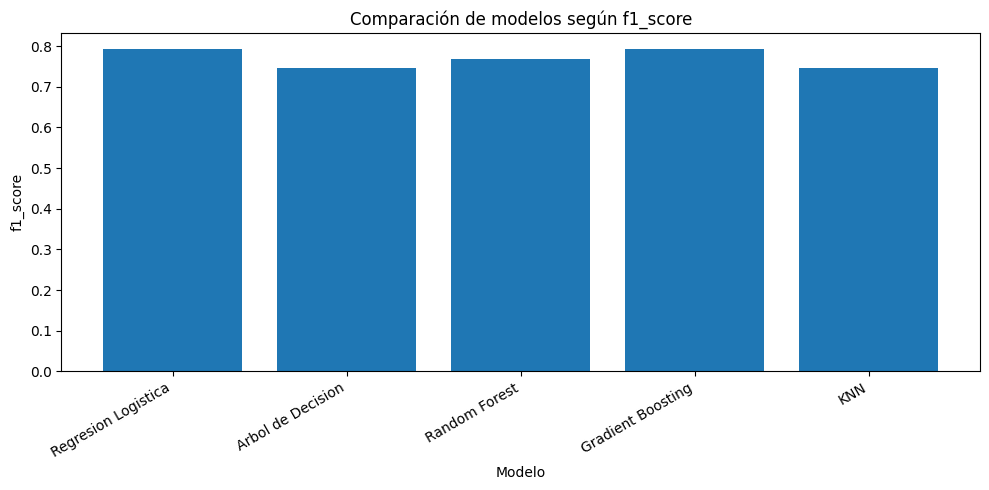


Matriz de confusión del mejor modelo:


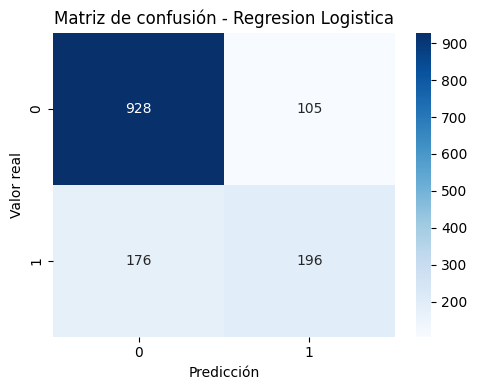


AGENTE 2 COMPLETADO
Modelo listo para el Agente 3 Comunicador.


In [7]:
agente2 = AgenteEntrenador(
    df=df_limpio,
    columna_objetivo="Churn"
)

resultados_entrenamiento, resumen_modelos = agente2.ejecutar()

# AGENTE 3: COMUNICADOR
# Responsabilidad:
# - Recibir los resultados del Agente 2
# - Construir un prompt con métricas y modelo ganador
# - Usar un modelo Transformer para generar un reporte
# - Guardar el informe final en un archivo .txt

In [8]:
class AgenteComunicador:
    """
    Agente 3 del sistema multiagente.

    Este agente recibe los resultados del entrenamiento y genera
    un informe académico en lenguaje natural usando Transformers.
    """

    def __init__(self, resultados_entrenamiento, nombre_dataset="Telco Customer Churn"):
        self.resultados = resultados_entrenamiento
        self.nombre_dataset = nombre_dataset
        self.modelo_transformer = None
        self.reporte_final = ""

        print("=" * 60)
        print("AGENTE 3: COMUNICADOR INICIADO")
        print("=" * 60)

    def cargar_transformer(self):
        """
        Carga un modelo Transformer desde Hugging Face.

        Se usa FLAN-T5 porque funciona relativamente bien en Colab
        y no exige tanta memoria como modelos gigantes. Milagro menor
        dentro del ecosistema Python.
        """
        print("\nCargando modelo Transformer...")

        from transformers import pipeline

        try:
            self.modelo_transformer = pipeline(
                "text2text-generation",
                model="google/flan-t5-base",
                max_new_tokens=500
            )

            print("Modelo Transformer cargado correctamente: google/flan-t5-base")

        except Exception as error:
            print("No se pudo cargar el modelo Transformer.")
            print("Error:", error)
            self.modelo_transformer = None

    def construir_prompt(self):
        """
        Construye el prompt que se enviará al Transformer.

        Incluye:
        - Nombre del dataset
        - Tipo de problema
        - Modelo ganador
        - Métricas del modelo
        - Comparación con otros modelos
        """
        tipo_problema = self.resultados["tipo_problema"]
        mejor_modelo = self.resultados["mejor_modelo"]
        mejor_metrica = self.resultados["mejor_metrica"]
        metricas = self.resultados["metricas"]
        todos_los_modelos = self.resultados["todos_los_modelos"]

        prompt = f"""
Genera un informe académico en español sobre un sistema multiagente de Machine Learning.

Dataset utilizado: {self.nombre_dataset}
Tipo de problema detectado: {tipo_problema}
Modelo seleccionado como ganador: {mejor_modelo}
Métrica principal obtenida: {mejor_metrica}

Métricas del modelo ganador:
{metricas}

Comparación con todos los modelos evaluados:
{todos_los_modelos}

El informe debe explicar:
1. Qué hizo el Agente 1 Normalizador.
2. Qué hizo el Agente 2 Entrenador.
3. Qué hace el Agente 3 Comunicador.
4. Por qué se seleccionó el modelo ganador.
5. Qué significan las métricas obtenidas.
6. Qué conclusiones se pueden obtener sobre la predicción de churn.
7. Recomendaciones finales para una empresa de telecomunicaciones.

Redacta el informe con tono profesional, claro y académico.
"""

        return prompt

    def generar_reporte_con_transformer(self, prompt):
        """
        Envía el prompt al modelo Transformer y obtiene el texto generado.
        """
        print("\nGenerando reporte con Transformer...")

        if self.modelo_transformer is None:
            print("No hay modelo Transformer disponible.")
            return ""

        try:
            respuesta = self.modelo_transformer(prompt)

            texto_generado = respuesta[0]["generated_text"]

            print("Reporte generado con Transformer.")
            return texto_generado

        except Exception as error:
            print("Error al generar el reporte con Transformer.")
            print("Error:", error)
            return ""

    def generar_reporte_respaldo(self):
        """
        Genera un reporte manual si el Transformer falla.

        Esto evita que el proyecto quede muerto solo porque Colab
        decidió convertirse en una piedra decorativa.
        """
        tipo_problema = self.resultados["tipo_problema"]
        mejor_modelo = self.resultados["mejor_modelo"]
        mejor_metrica = self.resultados["mejor_metrica"]
        metricas = self.resultados["metricas"]

        reporte = f"""
INFORME FINAL DEL SISTEMA MULTIAGENTE

1. DESCRIPCIÓN GENERAL

Se desarrolló un sistema multiagente de Machine Learning utilizando el dataset
{self.nombre_dataset}. El objetivo principal fue predecir la variable Churn,
es decir, identificar si un cliente tiene probabilidad de abandonar el servicio
de una empresa de telecomunicaciones.

El sistema está compuesto por tres agentes:

- Agente 1 Normalizador:
  Se encargó de cargar el dataset original, eliminar columnas innecesarias,
  tratar valores faltantes, convertir variables categóricas a numéricas,
  escalar variables numéricas y generar un dataset limpio.

- Agente 2 Entrenador:
  Recibió el dataset procesado, detectó automáticamente que el problema era de
  tipo {tipo_problema}, entrenó varios modelos de Machine Learning y comparó
  sus métricas para seleccionar el mejor modelo.

- Agente 3 Comunicador:
  Recibió los resultados del entrenamiento y generó este reporte en lenguaje
  natural utilizando un enfoque basado en Transformer o, en caso de error,
  una plantilla automática.

2. MODELO SELECCIONADO

El modelo seleccionado como ganador fue:

{mejor_modelo}

Este modelo obtuvo una métrica principal de:

{mejor_metrica:.4f}

Fue seleccionado porque presentó el mejor rendimiento general entre los modelos
evaluados por el Agente 2.

3. MÉTRICAS DEL MODELO GANADOR

Las métricas obtenidas por el modelo ganador fueron:

{metricas}

En problemas de clasificación como la predicción de churn, estas métricas
permiten analizar no solo cuántas predicciones fueron correctas, sino también
qué tan bien el modelo identifica clientes que realmente podrían abandonar
el servicio.

4. INTERPRETACIÓN DE RESULTADOS

El modelo permite anticipar clientes con riesgo de abandono. Esto puede ayudar
a una empresa de telecomunicaciones a tomar decisiones preventivas, como ofrecer
promociones, mejorar la atención al cliente o revisar contratos antes de que el
cliente decida cancelar el servicio.

5. CONCLUSIONES

El sistema multiagente cumplió con el flujo solicitado:

Dataset CSV original
↓
Agente 1 Normalizador
↓
Dataset limpio
↓
Agente 2 Entrenador
↓
Modelo y métricas
↓
Agente 3 Comunicador
↓
Reporte final en lenguaje natural

La arquitectura permite separar responsabilidades y automatizar el proceso de
Machine Learning desde la limpieza de datos hasta la explicación final de los
resultados.

6. RECOMENDACIONES

Se recomienda:
- Probar más modelos en futuras versiones.
- Ajustar hiperparámetros.
- Usar técnicas para manejar desbalance de clases.
- Incorporar explicabilidad con importancia de variables.
- Actualizar el modelo periódicamente con nuevos datos.
"""

        return reporte

    def mostrar_reporte(self):
        """Muestra el reporte final."""
        print("\n" + "=" * 60)
        print("REPORTE FINAL GENERADO")
        print("=" * 60)
        print(self.reporte_final)

    def guardar_reporte(self, nombre_archivo="reporte_final_churn.txt"):
        """Guarda el reporte final en un archivo de texto."""
        with open(nombre_archivo, "w", encoding="utf-8") as archivo:
            archivo.write(self.reporte_final)

        print(f"\nReporte guardado como: {nombre_archivo}")

    def ejecutar(self):
        """
        Ejecuta todo el flujo del Agente 3.
        """
        self.cargar_transformer()

        prompt = self.construir_prompt()

        reporte_transformer = self.generar_reporte_con_transformer(prompt)

        if reporte_transformer and len(reporte_transformer.strip()) > 100:
            self.reporte_final = reporte_transformer
        else:
            print("\nSe usará reporte de respaldo.")
            self.reporte_final = self.generar_reporte_respaldo()

        self.mostrar_reporte()
        self.guardar_reporte()

        print("\nAGENTE 3 COMPLETADO")
        print("Reporte final listo.")

        return self.reporte_final

In [9]:
agente3 = AgenteComunicador(
    resultados_entrenamiento=resultados_entrenamiento,
    nombre_dataset="Telco Customer Churn"
)

reporte_final = agente3.ejecutar()

AGENTE 3: COMUNICADOR INICIADO

Cargando modelo Transformer...


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

No se pudo cargar el modelo Transformer.
Error: "Unknown task text2text-generation, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

Generando reporte con Transformer...
No hay modelo Transformer disponible.

Se usará reporte de respaldo.

REPORTE FINAL GENERADO

INFORME FINAL DEL SISTEMA MULTIAGENTE

1. DESCRIPCIÓN GENERAL

Se desarrolló un sistema multiagente de Machine Learning utilizando el dataset


In [10]:
print("="*60)
print("SISTEMA MULTIAGENTE COMPLETADO")
print("="*60)

print("Agente 1: Dataset normalizado correctamente")
print("Agente 2: Modelos entrenados y evaluados")
print("Agente 3: Reporte generado mediante Transformer")

print("\nRESULTADOS FINALES")
print("-"*40)
print(f"Tipo de problema: {resultados_entrenamiento['tipo_problema']}")
print(f"Modelo ganador: {resultados_entrenamiento['mejor_modelo']}")
print(f"Métrica principal: {resultados_entrenamiento['mejor_metrica']:.4f}")

SISTEMA MULTIAGENTE COMPLETADO
Agente 1: Dataset normalizado correctamente
Agente 2: Modelos entrenados y evaluados
Agente 3: Reporte generado mediante Transformer

RESULTADOS FINALES
----------------------------------------
Tipo de problema: clasificacion
Modelo ganador: Regresion Logistica
Métrica principal: 0.7928
